<a href="https://colab.research.google.com/github/comet-toolkit/comet_training/blob/main/punpy_with_errcorr_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Training Session - CoMet Toolkit: Uncertainties made easy**

#Exercise 2: Explore how to handle error correlations using the punpy tool.

## Objectives

In this exercise we will:

* Get familiar with how error correlation using the [**punpy**](https://punpy.readthedocs.io/en/latest/) tool.
* Propagate uncertainties and error correlation on manually provided input data through a simple measurement functions using [**punpy**](https://punpy.readthedocs.io/en/latest/).
* Explore the various ways uncertainties with different error correlations can be propagated.


## *Step 1* - Set up the environment

First, we again install the punpy package for uncertainty propagation.

In [1]:
!pip install punpy>=1.0.6

Please hit `Runtime > Restart Session` to properly load these packages into your Google Colab environment...

Then, import the relevant python packages required in this training:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import punpy

❗Note: If this import fails, it is likely because the pip installation has not properly updated in the Google colab session. Please restart session (in runtime tab above).

## *Step 2* - Define measurement function and input data

In this exercise, our aim is to get familiar with the basic functionality for dealing with error correlation in punpy. We will use the same example as in exercise 1 using a very basic sensor calibration, where we have some digital numbers for the signal (referred to as L0) and the gains (typically obtained from a lab calibration) to convert these to a physical quantity (referred to as L1). E.g., this could be a radiance measurement collected by an in-situ instrument.  

First, we define our measurement function. For use in punpy, this measurement function needs to be written as a Python function that takes the input quantities (on which we have uncertainties available) as arguments and the measurand (to which we want to propagate the uncertainties) as return. For some further information on measurement functions, input quantities and measurand, see the [CoMet webpage](https://www.comet-toolkit.org/user-guide/theory/).

In [3]:
# your measurement function
def calibrate(L0,gains):
   return L0*gains

Here, the measurement function is a very simple analytical function. However, in practice, this measurement function can contain as much complexity (including calls to other packages/external software, ...) as needed. To some extent, the measurement function is treated as a black box, as long as the measurand and input quantities are structured as expected.

Next, we define some example input data. For your own use case, you need to have this information available from other sources (i.e. the input uncertainties need to be understood prior to using punpy). We here now separate random and systematic uncertainties (though the total adds up to the same uncertainties as in exercise 1).

In [4]:
# your data
wavs = np.array([350,450,550,650,750])
L0 = np.array([0.43,0.8,0.7,0.65,0.9])
gains = np.array([23,26,28,29,31])

# your uncertainties
L0_ur = L0*0.05                             # 5% random uncertainty
L0_us = np.ones(5)*0.03                     # systematic uncertainty of 0.03

gains_ur = np.array([0.5,0.7,0.6,0.4,0.1])  # random uncertainty
gains_us = np.array([0.1,0.2,0.1,0.4,0.3])  # systematic uncertainty


## *Step 3* - Propagate the random and systematic uncertainties

After defining the data, the resulting uncertainty budget can then be calculated with punpy using the Monte Carlo (MC) method. First, we propagate the random and systematic uncertainties separately, and then combine the resulting L1 uncertainties.

In [5]:
# initialise a punpy MCpropagation object with 10000 MC samples
prop=punpy.MCPropagation(10000)

# apply the measuremnet function to calculate the measurand from the input quantities
L1=calibrate(L0,gains)

# propagate random uncertainties
# The format for the inputs is propagate_random(measurement function, [list of function inputs], [list of uncertainties in the same order of inputs])
L1_ur=prop.propagate_random(calibrate,[L0,gains],
      [L0_ur,gains_ur])

# propagate systematic uncertainties
L1_us=prop.propagate_systematic(calibrate,[L0,gains],
      [L0_us,gains_us])

# combine random and systematic uncertainties
L1_ut=(L1_ur**2+L1_us**2)**0.5


# print the results
print("L1:", L1)
print("L1_ur:", L1_ur)
print("L1_us:", L1_us)
print("L1_ut:", L1_ut)

L1: [ 9.89 20.8  19.6  18.85 27.9 ]
L1_ur: [0.53705874 1.18339262 1.07409154 0.96629132 1.4028568 ]
L1_us: [0.68929805 0.79389631 0.840441   0.90541973 0.96569213]
L1_ut: [0.87382143 1.42502261 1.36382319 1.3241993  1.70310555]


To know the error correlation of the total uncertainties, we need to sum the covariance of the random and systematic uncertainties. The error correlations can be converted to error covariance and back using some helper functions.

In [6]:
# define error correlation for random and systematic uncertainties
L1_rand_err_corr=np.eye(len(L1_ur))                     # random uncertainties have an identity matrix as the error correlation
L1_sys_err_corr=np.ones((len(L1_us),len(L1_us)))             # systematic uncertainties have a matrix full of ones as the error correlation

# calculate random and systematic error covariance matrices
L1_rand_cov=punpy.convert_corr_to_cov(L1_rand_err_corr,L1_ur)
L1_sys_cov=punpy.convert_corr_to_cov(L1_sys_err_corr,L1_us)

# combine random and systematic error covariance matrices and calculate the total error correlation matrix
L1_cov=L1_rand_cov + L1_sys_cov
L1_corr=punpy.correlation_from_covariance(L1_cov)

print("L1_cov:\n",L1_cov)
print("L1_corr:\n",L1_corr)

L1_cov:
 [[0.76356389 0.54723117 0.57931434 0.62410405 0.6656497 ]
 [0.54723117 2.03068943 0.66722301 0.71880938 0.76665942]
 [0.57931434 0.66722301 1.8600137  0.76095186 0.81160726]
 [0.62410405 0.71880938 0.76095186 1.7535038  0.87435671]
 [0.6656497  0.76665942 0.81160726 0.87435671 2.9005685 ]]
L1_corr:
 [[1.         0.43946712 0.48610884 0.53936276 0.44728207]
 [0.43946712 1.         0.34331374 0.38092425 0.31589239]
 [0.48610884 0.34331374 1.         0.42135268 0.34941882]
 [0.53936276 0.38092425 0.42135268 1.         0.38769815]
 [0.44728207 0.31589239 0.34941882 0.38769815 1.        ]]


/usr/local/lib/python3.12/dist-packages/comet_maths/linear_algebra/matrix_conversion.py:32: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  correlation = np.divide(covariance, outer_v, where=outer_v != 0)


We can then plot and inspect the results:

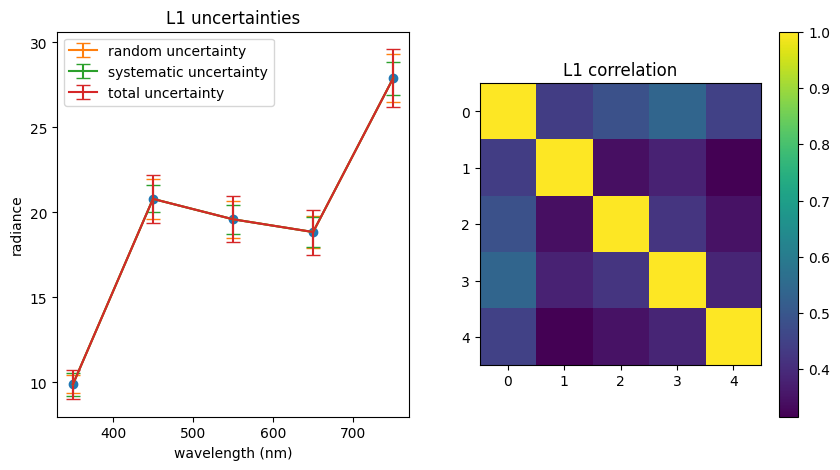

In [7]:
# define plot to show results
def make_plots_L1(L1,L1_ur=None,L1_us=None,L1_ut=None,L1_corr=None):
  if L1_cov is not None:
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))
  else:
    fig,ax1 = plt.subplots(1,figsize=(5,5))

  ax1.plot(wavs,L1,"o")
  if L1_ur is not None:
    ax1.errorbar(wavs,L1,yerr=L1_ur,label="random uncertainty",capsize=5)
  if L1_us is not None:
    ax1.errorbar(wavs,L1,yerr=L1_us,label="systematic uncertainty",capsize=5)
  if L1_ut is not None:
    ax1.errorbar(wavs,L1,yerr=L1_ut,label="total uncertainty",capsize=5)
  ax1.legend()
  ax1.set_xlabel("wavelength (nm)")
  ax1.set_ylabel("radiance")
  ax1.set_title("L1 uncertainties")
  if L1_cov is not None:
    ax2.set_title("L1 correlation")
    cov_plot=ax2.imshow(L1_corr)
    plt.colorbar(cov_plot,ax=ax2)
  plt.show()
make_plots_L1(L1,L1_ur,L1_us,L1_ut,L1_corr) # make and display plot

## *Step 4* - Why does error correlation matter?

The results in the previous step were identical to those in exercise 1, so why does it matter what the error correlation is? Any time we are combining measurements and want to know the uncertainties on the resulting output, the error correlations do play an important role. For example if we are averaging data and assume the total uncertainties have a random error correlation (as in exercise 1):

In [8]:
L1_avg=np.mean(L1)
print("L1 average:", L1_avg)
L1_avg_ut = prop.propagate_random(np.mean,[L1],
      [L1_ut])
print("L1 average uncertainty:", L1_avg_ut)

L1 average: 19.408
L1 average uncertainty: 0.6182721700185447


However if we use the error correlation we calculated in the previous example:


In [9]:
L1_avg_ur = prop.propagate_random(np.mean,[L1],
      [L1_ur])
print("L1 average random uncertainty:", L1_avg_ur)
L1_avg_us = prop.propagate_systematic(np.mean,[L1],
      [L1_us])
print("L1 average systematic uncertainty:", L1_avg_us)
L1_avg_ut_errcorr = (L1_avg_ur**2 + L1_avg_us**2)**0.5
print("L1 average total uncertainty (errcorr):", L1_avg_ut_errcorr)

L1 average random uncertainty: 0.4809604597545846
L1 average systematic uncertainty: 0.8384002044566152
L1 average total uncertainty (errcorr): 0.9665598101929521


Note that this is now different to the previous answer. Without correctly taking into account the error correlation, we would have significantly underestimated the uncertainties.

## *Step 5* - Propagate uncertainties with an error correlation matrix

Instead of separately propagating the random and systematic uncertainties, we can also achieve the same result by first combining the random and systematic uncertainties on the input, and then propagating the total uncertainties and their error correlation. In this case, the error correlation needs to be explicitly passed to the `propagate_standard' function.

L1: [ 9.89 20.8  19.6  18.85 27.9 ]
L1_ut: [0.86930218 1.42818184 1.36457506 1.33404323 1.6991133 ]
L1_corr:
 [[1.         0.44770999 0.48605735 0.52449921 0.4267377 ]
 [0.44770999 1.         0.35630598 0.38435274 0.31859272]
 [0.48605735 0.35630598 1.         0.411137   0.33376728]
 [0.52449921 0.38435274 0.411137   1.         0.39018078]
 [0.4267377  0.31859272 0.33376728 0.39018078 1.        ]]
L1 average total uncertainty (errcorr): 0.9698831945536588


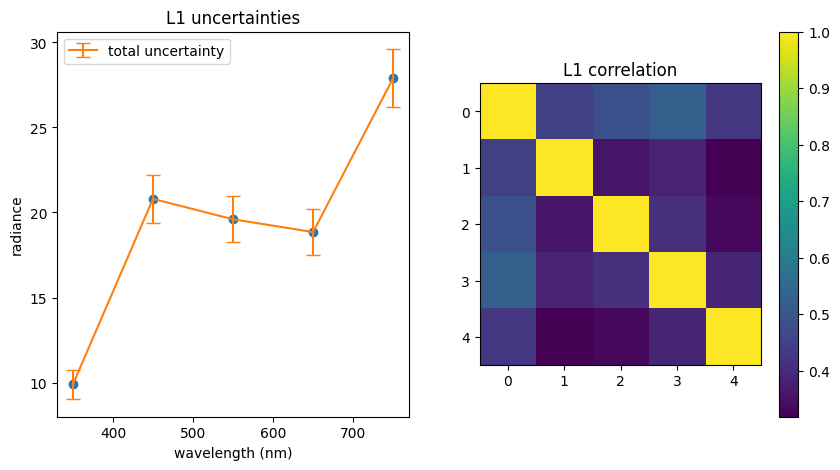

In [10]:
# first combine the random and systemtic uncertainties on the inputs
L0_ut=(L0_ur**2+L0_us**2)**0.5
gains_ut=(gains_ur**2+gains_us**2)**0.5

# combine the error correlation matrices on the inputs (by combining the error covariances)
L0_cov=punpy.convert_corr_to_cov(np.eye(len(L0_ur)),L0_ur)+\
       punpy.convert_corr_to_cov(np.ones((len(L0_us),len(L0_us))),L0_us)
L0_corr=punpy.correlation_from_covariance(L0_cov)

gains_cov=punpy.convert_corr_to_cov(np.eye(len(gains_ur)),gains_ur)+\
       punpy.convert_corr_to_cov(np.ones((len(gains_us),len(gains_us))),gains_us)
gains_corr=punpy.correlation_from_covariance(gains_cov)

# propagate the combined uncertainties and error correlation
L1_ut, L1_corr=prop.propagate_standard(calibrate,[L0,gains],
      [L0_ut,gains_ut],[L0_corr,gains_corr], return_corr=True)

# propagate the average and its uncertainty using the previously determined error correlation
L1_avg_ut_errcorr = prop.propagate_standard(np.mean,[L1],
      [L1_ut],[L1_corr])


# print results
print("L1:", L1)
print("L1_ut:", L1_ut)
print("L1_corr:\n", L1_corr)
print("L1 average total uncertainty (errcorr):", L1_avg_ut_errcorr)
make_plots_L1(L1,L1_ut=L1_ut,L1_corr=L1_corr)

## **Exercise**

Let's again add an additional variable to the measurement function, and propagate uncertainties.
Either propagate the random and systematic uncertainties separately and combine them at the end, or combine them first.
Here is the updated measurement function with the additional input data:

In [11]:
# updated measurement function
def calibrate(L0,gains,dark):
   return (L0-dark)*gains

# additional input quantity
dark = np.array([0.05,0.03,0.04,0.05,0.06])
dark_ur = np.array([0.02,0.02,0.02,0.02,0.02])  # random uncertainty

Try this yourself: propagate the uncertainties through this measurement function, based on the examples above. (❗Note: there are no systematic uncertainties on the darks, set them to zero if required).

L1: [ 9.89 20.8  19.6  18.85 27.9 ]
L1_ut: [0.98648311 1.51747972 1.47722686 1.44707367 1.8144007 ]
L1_corr:
 [[1.         0.37364373 0.41908475 0.42861335 0.3647648 ]
 [0.37364373 1.         0.31242463 0.33527951 0.2924099 ]
 [0.41908475 0.31242463 1.         0.35662135 0.31147972]
 [0.42861335 0.33527951 0.35662135 1.         0.33246712]
 [0.3647648  0.2924099  0.31147972 0.33246712 1.        ]]
L1 average total uncertainty (errcorr): 1.0072832253466986


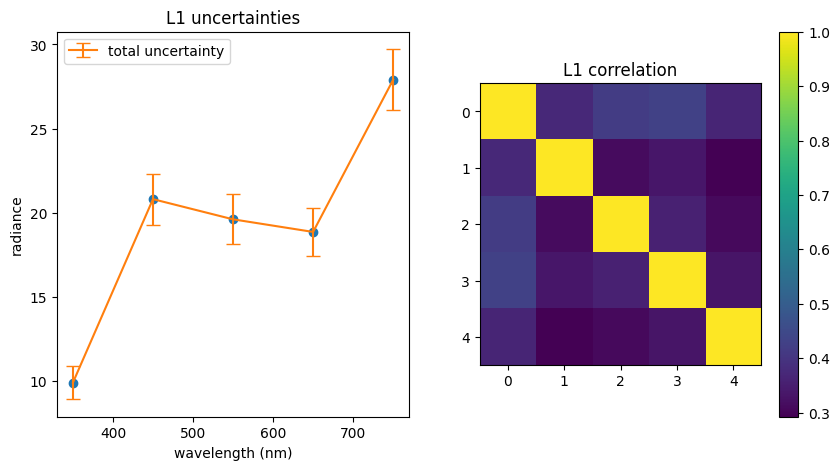

In [12]:
# Enter your code here
# first combine the random and systemtic uncertainties on the inputs
L0_ut=(L0_ur**2+L0_us**2)**0.5
gains_ut=(gains_ur**2+gains_us**2)**0.5
dark_ut=dark_ur

# combine the error correlation matrices on the inputs (by combining the error covariances)
L0_cov=punpy.convert_corr_to_cov(np.eye(len(L0_ur)),L0_ur)+\
       punpy.convert_corr_to_cov(np.ones((len(L0_us),len(L0_us))),L0_us)
L0_corr=punpy.correlation_from_covariance(L0_cov)

gains_cov=punpy.convert_corr_to_cov(np.eye(len(gains_ur)),gains_ur)+\
       punpy.convert_corr_to_cov(np.ones((len(gains_us),len(gains_us))),gains_us)
gains_corr=punpy.correlation_from_covariance(gains_cov)

dark_corr=np.eye(len(dark_ur))

# propagate the combined uncertainties and error correlation
L1_ut, L1_corr=prop.propagate_standard(calibrate,[L0,gains,dark],
      [L0_ut,gains_ut,dark_ut],[L0_corr,gains_corr,dark_corr], return_corr=True)

# propagate the average and its uncertainty using the previously determined error correlation
L1_avg_ut_errcorr = prop.propagate_standard(np.mean,[L1],
      [L1_ut],[L1_corr])


# print results
print("L1:", L1)
print("L1_ut:", L1_ut)
print("L1_corr:\n", L1_corr)
print("L1 average total uncertainty (errcorr):", L1_avg_ut_errcorr)
make_plots_L1(L1,L1_ut=L1_ut,L1_corr=L1_corr)



## *Step 6* - Error correlation between variables

In addition to having a correlation along one or more dimensions of a given variable, it is also possible that two variables are correlated (for example because they are measured using the same sensor). This can be specified in punpy by using the corr_between keyword. In the example below, the systematic errors in the darks and L0 data are fully correlated.

/usr/local/lib/python3.12/dist-packages/comet_maths/linear_algebra/matrix_calculation.py:274: UserWarning: One of the correlation matrices is not positive definite. It has been slightly changed (maximum difference of 2.220446049250313e-16) to accomodate our method.
  warnings.warn(


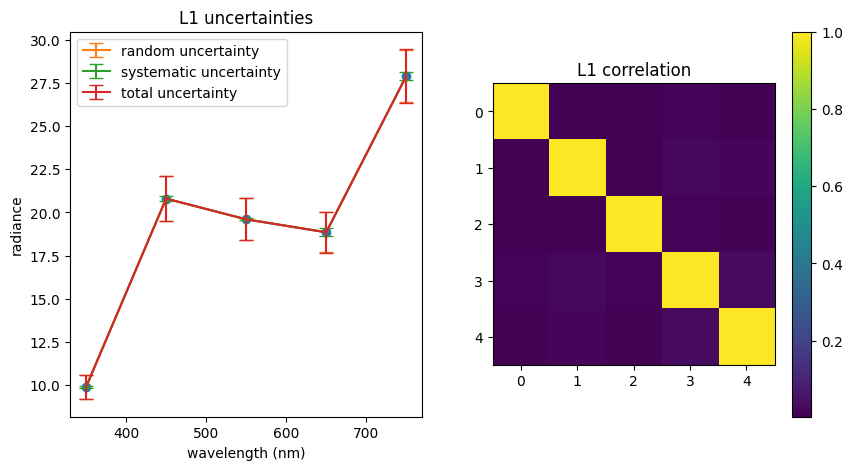

In [13]:
# We here define some systematic uncertainties for the darks, which are the same as for the digital numbers
dark_us = L0_us

# We then define how the errors for the different variables are correlated
corr_var=np.array([[1,0,1],   # here a 1 means the variables are fully correlated, and a 0 means uncorrelated
                   [0,1,0],   # on the diagonal there are 1's because each variable is fully correlated with itself
                   [1,0,1]])  # there are also 1's on the (0,2) and (2,0) locations, indicating the 1st and last variable (i.e. L0 and dark) are correlated

# We then recalculate the uncertainties and make a plot
L1_ur=prop.propagate_random(calibrate,[L0,gains,dark],
      [L0_ur,gains_ur,dark_ur])
L1_us=prop.propagate_systematic(calibrate,[L0,gains,dark],
      [L0_us,gains_us,dark_us],corr_between=corr_var)

L1_ut=(L1_ur**2+L1_us**2)**0.5

L1_cov=punpy.convert_corr_to_cov(np.eye(len(L1_ur)),L1_ur)+\
       punpy.convert_corr_to_cov(np.ones((len(L1_us),len(L1_us))),L1_us)
L1_corr=punpy.correlation_from_covariance(L1_cov)

L1_avg_ut_errcorr = prop.propagate_standard(np.mean,[L1],
      [L1_ut],[L1_corr])

make_plots_L1(L1,L1_ur,L1_us,L1_ut,L1_corr)

## *Step 7* - Punpy keywords

There are many keywords that can be passed to the punpy functions to control the detailed behaviour. For a detailed description refer to the [punpy documentation](https://punpy.readthedocs.io/en/latest/content/generated/punpy.mc.mc_propagation.MCPropagation.propagate_standard.html). An additional features we would like to highlight is the ability to return the individual MC samples that were used, for manual inspection:

In [14]:
L1_ut, L1_corr, MCsamples_L1, MCsamples_L0=prop.propagate_standard(calibrate,[L0,gains,dark],
      [L0_ut,gains_ut,dark_ur],[L0_corr,gains_corr,"rand"], return_corr=True, return_samples=True)  # the return_samples keyword is set to True
print("MC samples L0:", MCsamples_L0)
print("MC samples L1:", MCsamples_L1)

MC samples L0: [array([[0.43511119, 0.806918  , 0.69631837, 0.6121184 , 0.86337953],
        [0.38532899, 0.7795789 , 0.65641628, 0.63848318, 0.92800401],
        [0.38255407, 0.73461871, 0.70313142, 0.60082316, 0.84697122],
        ...,
        [0.47734797, 0.80314927, 0.67334152, 0.65041048, 0.95105825],
        [0.43717228, 0.74997684, 0.74386379, 0.64183338, 0.91017222],
        [0.50508404, 0.82028572, 0.75793841, 0.68042239, 0.93784485]],
       shape=(10000, 5))
 array([[22.8400057 , 26.46165812, 27.87784025, 28.92062041, 30.79958198],
        [23.05707311, 26.54495066, 28.83511901, 29.44874882, 31.29920405],
        [23.69255158, 26.1684486 , 28.15111131, 28.77365953, 31.12547667],
        ...,
        [23.2156601 , 25.35738309, 27.59653761, 28.97592641, 30.7847803 ],
        [22.18177356, 26.74923694, 27.64174958, 29.06963349, 31.20615555],
        [22.03669736, 26.92361618, 27.96757897, 28.84458857, 30.5862293 ]],
       shape=(10000, 5))
 array([[ 0.05919158,  0.04231416,  0

In these dark samples, there are some negative values. Depending on the use case, this might be considered unphysical.

Furthermore, it is possible to use different probability density functions (PDF) instead of the default Gaussian PDF. E.g., it is possible to define a lower boundary for the values in the MCsamples of the inputs, and thus avoid negative outputs:

In [15]:
L1_ut, MCsamples_L1, MCsamples_L0 = prop.propagate_standard(calibrate,[L0,gains,dark],
      [L0_ut,gains_ut,dark_ur],[L0_corr,gains_corr,"rand"], return_corr=False, return_samples=True, pdf_shape="truncated_gaussian", pdf_params={"min":0.})  # the pdf shape is set to truncated gaussian, and pdf_param is a dictionary that allows to set the minimum and maximum value
print("MC samples L0:", MCsamples_L0)
print("MC samples L1:", MCsamples_L1)

MC samples L0: [array([[0.47436456, 0.88146299, 0.71086713, 0.6864442 , 0.95374937],
        [0.44361556, 0.82073103, 0.72093757, 0.68617098, 0.87582804],
        [0.44103327, 0.7961209 , 0.70427929, 0.69062677, 0.93828389],
        ...,
        [0.47713453, 0.85429412, 0.69813909, 0.68210441, 0.93425582],
        [0.43679358, 0.77850778, 0.68323484, 0.6549676 , 0.9188138 ],
        [0.50888722, 0.83675754, 0.73928026, 0.68766947, 1.02390432]],
       shape=(10000, 5))
 array([[23.31932315, 26.57799074, 28.08582608, 29.89965792, 31.29630682],
        [22.67929669, 24.96567504, 28.03361489, 28.17231074, 30.64143273],
        [23.06505784, 25.6651948 , 28.24098778, 29.0207685 , 31.17165501],
        ...,
        [22.23178304, 25.4783949 , 28.22085272, 29.25998268, 30.75496107],
        [22.62785724, 25.81655463, 28.65168697, 28.90104892, 31.03235134],
        [22.19664457, 26.87043074, 27.71385293, 28.94355813, 31.0542401 ]],
       shape=(10000, 5))
 array([[0.03160356, 0.02004676, 0.03

This version has no negative values. (❗Note: this does artificially reduce the uncertainties, so use with caution!)